In [1]:
import torch
import torch.nn as nn
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from models.vae import VariationalAutoencoders as VAE

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the trained model
latent_dim = 128
model = VAE(latent_dim=latent_dim).to(device)

checkpoint_path = 'vae_celeba_best.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from epoch {checkpoint['epoch']} with loss {checkpoint['loss']:.4f}")
else:
    print("Checkpoint not found. Please train the model first.")

model.eval()

Using device: cuda
Loaded model from epoch 10 with loss 460.5619


VariationalAutoencoders(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=16384, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=16384, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=16384, bias=True)
  (decode): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 8, 8))
    (

In [18]:
# Generate sample images
num_samples = 16
with torch.no_grad():
    z = torch.randn(num_samples, latent_dim).to(device)
    # Decode
    d = model.fc_decode(z)
    samples = model.decode(d)

# Denormalize from [-1, 1] to [0, 1]
samples = (samples + 1) / 2
samples = samples.clamp(0, 1)

# Convert to numpy for plotting
samples = samples.cpu().numpy()
samples = np.transpose(samples, (0, 2, 3, 1))  # (N, H, W, C)

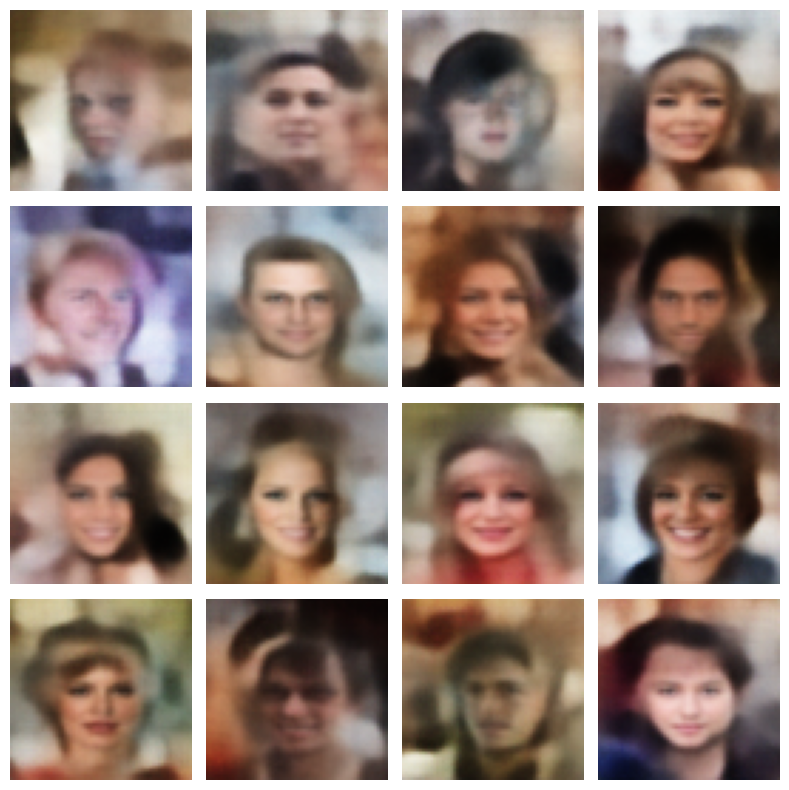

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
# Save the generated images
import os
output_dir = 'outputs/samples'
os.makedirs(output_dir, exist_ok=True)

for i in range(num_samples):
    img = (samples[i] * 255).astype(np.uint8)
    pil_img = Image.fromarray(img)
    pil_img.save(os.path.join(output_dir, f'sample_{i+1:02d}.png'))

print(f"Saved {num_samples} sample images to {output_dir}/")

Saved 16 sample images to outputs/samples/
